<a href="https://colab.research.google.com/github/sanjivinicarmel/AgriDataAnalysis2016/blob/main/LSTM_architecture_Demo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets

Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

#installing hugging face satasets
#numpy/pandas for data handling, matplotlib for plotting, Keras for building the neural network, sklearn for encoding labels and evaluating results.

Loading the dataset

In [ ]:
dataset = load_dataset("dair-ai/emotion")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

#Downloads the "emotion" dataset (short text sentences labeled with emotions) and converts it into pandas DataFrames

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


Checking dataset

In [ ]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

#Checks how many rows exist and how balanced the emotion classes are.

(16000, 2)
(2000, 2)


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


Converting Labels to Emotional Name

In [ ]:
emotion_names = {
    0:"sadness",
    1:"joy",
    2:"love",
    3:"anger",
    4:"fear",
    5:"surprise"
}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

train_df.head()

#The dataset stores labels as numbers; this adds a readable emotion column.

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Label Encoding

In [ ]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])

#Converts emotion names back into numeric IDs the model can learn from (this re-encoding is a bit redundant since the numeric label column already existed, but it works fine).

Tokenization

In [ ]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size,
                      oov_token="<OOV>")

tokenizer.fit_on_texts(train_df["text"])

#Builds a vocabulary of the 10,000 most common words in the training text. Words outside this vocabulary become <OOV> (out of vocabulary).

Converting tokens to sequences

In [ ]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
#Converts each sentence into a list of numbers (word IDs), since neural networks need numbers, not raw text.
X_test = tokenizer.texts_to_sequences(test_df["text"])

Padding

In [ ]:
max_length = 40
#Makes every sentence the same length (40 tokens) by adding zeros at the end — needed because the model expects fixed-size input.

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")

Building the model

In [ ]:
model = Sequential()

model.add(
    Embedding(input_dim=vocab_size,
              output_dim=64,
              input_length=max_length)
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(32, activation="relu")
)

model.add(
    Dense(6, activation="softmax")
)

model.summary()

#Embedding: turns each word ID into a 64-dimensional vector (learns word meaning).
#LSTM(64): the core recurrent layer — reads the sequence of word vectors and captures context/order (good for text since word order matters).
#Dropout(0.5): randomly "turns off" 50% of neurons during training to prevent overfitting.
#Dense(32, relu): a regular fully-connected layer to learn combinations of features.
#Dense(6, softmax): final output layer — gives probabilities across the 6 emotion classes.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compiling the model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
#Sets how the model learns: Adam optimizer, cross-entropy loss (standard for multi-class classification), tracking accuracy.

Training the model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)
#Trains for 8 passes over the data, holding out 20% of training data to check performance on unseen data as it trains.


Epoch 1/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - accuracy: 0.3288 - loss: 1.6013 - val_accuracy: 0.3262 - val_loss: 1.5803
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.3556 - loss: 1.4500 - val_accuracy: 0.3716 - val_loss: 1.2544
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.4298 - loss: 1.0971 - val_accuracy: 0.4437 - val_loss: 1.1170
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.5098 - loss: 0.9625 - val_accuracy: 0.5044 - val_loss: 1.0410
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7142 - loss: 0.7260 - val_accuracy: 0.7678 - val_loss: 0.7455
Epoch 6/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.8756 - loss: 0.4168 - val_accuracy: 0.8550 - val_loss: 0.5369
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9063 - loss: 0.3061 - val_accuracy: 0.8681 - val_loss: 0.5007
Epoch 8/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.9292 - loss: 0.2225 - val_accuracy

Accuracy Plot

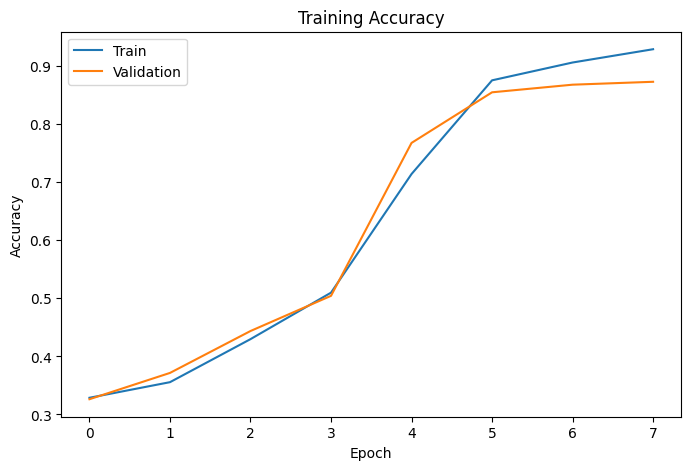

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

Loss Plot

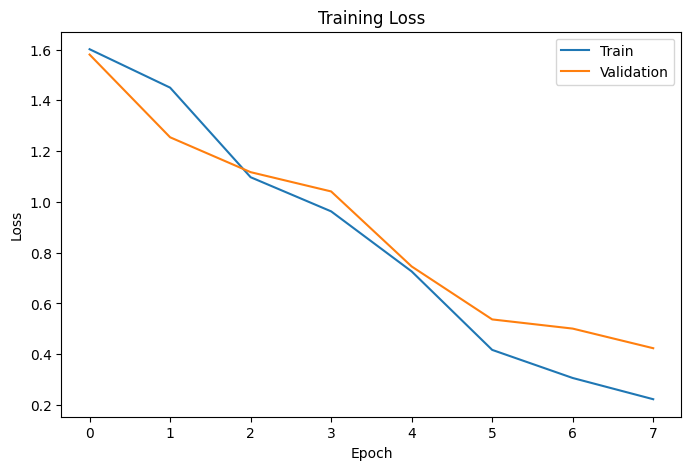

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()

Evaluation Of Model

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8640 - loss: 0.4632
Test Accuracy : 0.8640000224113464


Classification Model

In [ ]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       275
           1       0.70      0.87      0.78       224
           2       0.90      0.92      0.91       695
           3       0.71      0.83      0.76       159
           4       0.97      0.89      0.93       581
           5       0.29      0.12      0.17        66

    accuracy                           0.86      2000
   macro avg       0.74      0.75      0.74      2000
weighted avg       0.86      0.86      0.86      2000



Predicting your own sentence

In [ ]:
sentence = ["I feel like crying "]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

#increase the neuron, remove the dropout, fine tune

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Emotion: joy
